# Flow Matching: SU3 gauge theory on $4^4$ lattice

*Sep 24, 2025*

**[Javad Komijani (ETH Zurich)](mailto:jkomijani@gmail.com)**

# Example: SU(3)

In [1]:
import torch
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["text.usetex"] = True

In [2]:
from lattice_ml.gauge_tools import WilsonGaugeAction, GaugeLinkConv

from normflow.prior import SUnPrior

Gauge Equivariant if 1.101147699356938e-17 is approximately 0


## Dynamics function

The flow is defined as
$$
   \frac{dU_t}{dt} = f(U_t) U_t
$$
where $f(U_t)$ is in the algebra space of the group.
We call $f(U_t)$ the algbra dynamcis functions.

We now give a simple neural networ for the algebra dynamics functions.

In [3]:
action = WilsonGaugeAction(beta=6)


class SimpleAlgDynamcisFunc(torch.nn.Module):
    """Algebra dynamcis function for SU(3) matrices.

    This model takes as input the time `t` and the initial state matrix `x` and
    predicts a flow while ensuring the output remains antihermitian and traceless.
    """

    def __init__(self, in_channels=None, out_channels=None, ndim=4):
        """Initializes the SU3DynamicsFunc neural network."""
        super().__init__()

        #self.weight = torch.nn.Parameter(torch.rand(5) * 3 / 16)
        #self.powers = torch.arange(5).reshape(1, -1)
        self.conv = GaugeLinkConv(in_channels=in_channels, out_channels=out_channels, ndim=ndim)
        
    def forward(self, t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        """Computes the forward pass of the SU3 flow function.

        Given a time `t` and a matrix `x`, the function processes the input
        through the neural network and applies post-processing to ensure the
        output is antihermitian and traceless.

        Args:
            - t (torch.Tensor): A 0D or 1D tensor representing time.
              If 1D, it is of shape (batch_size,)
            - x (torch.Tensor): A complex-valued input tensor of shape
              (batch_size, 1, 3, 3).

        Returns:
            - torch.Tensor: A antihermitian, traceless tensor of shape
              (batch_size, 1, 3, 3).
        """
        x = self.conv(x,t)
        #shape = (-1, *[1]*(x.ndim - 1))
        #return action.algebra_force(x) * self.time_func(t).reshape(*shape)
        return action.algebra_force(x)

    def time_func(self, t):
        return torch.sum(self.weight * t.unsqueeze(-1) ** self.powers, dim=1)

    def wilson_forward(self, t, x):
        return action.algebra_force(x) * 3 / 16

In [4]:
training_samples = torch.load("/scratch/lturgut/cfgs_b6_200traj_15steps.pt", map_location="cuda:0")

from torch.utils.data import DataLoader, TensorDataset

batch_size = 256 // 4

dataset = TensorDataset(training_samples)

data_loader1 = DataLoader(
    dataset,
    batch_size = batch_size,
    shuffle = False
)

In [5]:
from lattice_ml.flow_matching import make_random_dataloader

num_samples, *sample_shape, n_c, n_c = training_samples.shape

prior = SUnPrior(n_c, sample_shape)

data_loader0 = make_random_dataloader(
    prior, batch_size, num_batches=num_samples//batch_size
)

In [6]:
from functools import partial

n_epochs = 200 #it was 200

train_kwargs = dict(
    n_epochs = n_epochs,
    hyperparam = dict(lr=0.095),  #tried (epoch 200): 0.2 (0.55), 0.1 (0.56) , 0.095 (0.56), 0.09 (0.56), 0.05 (0.14), 0.01 (0.17)
    #tried (epoch 300): 0.095 ()
    checkpoint_dict = dict(print_every=20),
    scheduler = partial(
        torch.optim.lr_scheduler.CosineAnnealingLR,                     
        T_max = int(1.01 * n_epochs)                                    
    )
)

In [7]:
from lattice_ml.flow_matching import LieTrainer

algebra_dynamics_fn = SimpleAlgDynamcisFunc()

trainer = LieTrainer(algebra_dynamics_fn)

trainer.execute(data_loader0, data_loader1, **train_kwargs)
print(algebra_dynamics_fn.conv.weight_poly)

20:51:26 | Training started for 200 epochs
20:52:26 | Epoch: 20 | loss: 3.0830
20:53:26 | Epoch: 40 | loss: 2.2266
20:54:26 | Epoch: 60 | loss: 2.1702
20:55:26 | Epoch: 80 | loss: 2.1504
20:56:26 | Epoch: 100 | loss: 2.1338
20:57:27 | Epoch: 120 | loss: 2.1091
20:58:27 | Epoch: 140 | loss: 2.0259
20:59:27 | Epoch: 160 | loss: 2.1699
21:00:27 | Epoch: 180 | loss: 2.0468
21:01:27 | Epoch: 200 | loss: 2.1043
21:01:27 | Training finished (cuda:0); TIME = 601 s


Parameter containing:
tensor([[[[[[-1.0570e-01,  4.8472e-04]]],


          [[[ 6.0196e-02,  7.9922e-03]]],


          [[[-1.1003e-01, -1.2631e-02]]],


          [[[ 5.9838e-02,  6.7245e-03]]],


          [[[-1.1376e-01,  4.7172e-04]]],


          [[[ 6.5594e-02,  2.3684e-03]]]],



         [[[[-1.0564e-01,  8.9184e-03]]],


          [[[ 5.1828e-02,  5.6277e-04]]],


          [[[-1.0973e-01,  1.6740e-02]]],


          [[[ 4.9322e-02,  3.3348e-03]]],


          [[[-9.8585e-02,  4.8377e-03]]],


          [[[ 4.7184e-02,  1.4471e-02]]]],



         [[[[-1.0828e-01,  1.9963e-02]]],


          [[[ 5.2265e-02,  5.0143e-03]]],


          [[[-1.1086e-01,  1.6545e-02]]],


          [[[ 5.4172e-02,  5.5761e-03]]],


          [[[-1.1087e-01, -3.0299e-03]]],


          [[[ 5.5904e-02,  1.5616e-03]]]],



         [[[[-1.0959e-01,  6.0298e-03]]],


          [[[ 5.0499e-02,  3.5931e-03]]],


          [[[-1.1781e-01,  1.6028e-02]]],


          [[[ 5.5508e-02,  1.5320e-03]]],


    

Text(0, 0.5, 'Loss')

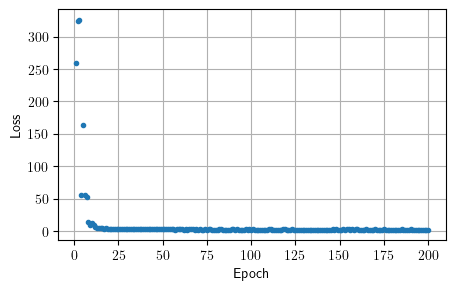

In [8]:
fig, axs = plt.subplots(1, 1, figsize=(5, 3))

loss = trainer.train_history['loss']
epochs = np.arange(1, len(loss) + 1)
plt.plot(epochs, loss, '.')

plt.grid()
plt.xlabel("Epoch")
plt.ylabel("Loss")

In [9]:
from lattice_ml.gauge_tools import compute_avg_trace_wilson_mxn_loop

from lattice_ml.integrate import lie_odeint

In [10]:
x = prior.sample(16)

dynamics_fn = lambda t, y: algebra_dynamics_fn(t, y) @ y

with torch.no_grad():
    y = lie_odeint(dynamics_fn, t_span=(0, 1), y0=x, num_steps=100)

In [11]:
(compute_avg_trace_wilson_mxn_loop(training_samples, 1, 1).mean(),
 compute_avg_trace_wilson_mxn_loop(y, 1, 1).mean(),
 compute_avg_trace_wilson_mxn_loop(y, 1, 1).std()
)

(tensor(0.5965, device='cuda:0'),
 tensor(0.4428, device='cuda:0'),
 tensor(0.0047, device='cuda:0'))

In [13]:
from lattice_ml.gauge_tools import compute_wilson_1x1_loop


theta_x = torch.linalg.eig(compute_wilson_1x1_loop(x, 0, 1))[0].angle()
theta_y = torch.linalg.eig(compute_wilson_1x1_loop(y, 0, 1))[0].angle()

theta_test = torch.linalg.eig(compute_wilson_1x1_loop(training_samples, 0, 1))[0].angle()

In [14]:
grab = lambda x: x.detach().cpu().numpy()

theta_x = grab(theta_x)
theta_y = grab(theta_y)

theta_test = np.array([grab(q) for q in theta_test])

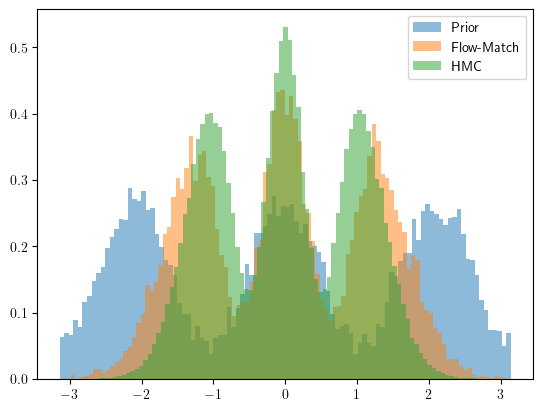

In [15]:
plt.hist(theta_x.ravel(), label = 'Prior', bins=100, density=True, alpha=0.5)
plt.hist(theta_y.ravel(), label = 'Flow-Match', bins=100, density=True, alpha=0.5)
plt.hist(theta_test.ravel(), label = 'HMC', bins=100, density=True, alpha=0.5)

plt.legend();

## Visualize the flow of eigen-angles of Wilson 1x1 loops

In [ ]:
from lattice_ml.functions import pow_special_unitary_group

In [ ]:
u_0 = prior.sample(num_samples).unsqueeze(1)  # axis 1: simulation time
u_1 = training_samples.unsqueeze(1)  # axis: simulation time


t_eval = np.linspace(0, 1, 100)

# Note that t must be broadcastable to eigenvalues of u_0 & u_1 matrices
t = torch.from_numpy(t_eval).reshape(1, -1, *(1,)*(u_0.ndim - 3))

u_t = pow_special_unitary_group(u_1 @ u_0.adjoint(), t) @ u_0

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

In [ ]:
from lattice_ml.linalg import eigu


w1x1_u_t = compute_wilson_1x1_loop(u_t, 0, 1, prefix_dims=2)

theta = eigu(w1x1_u_t)[0].angle().movedim(0, 1)


grab = lambda x: x.detach().cpu().numpy()

# reshape to (batch, time, -1, 3 eigenanlges)
theta = grab(theta.reshape(*theta.shape[:2], -1, 3))

shape = theta.shape

t_eval_reshaped = np.tile(t_eval[:, None], (1, np.prod(shape[1:]))).reshape(*shape)

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(10, 5), gridspec_kw={'width_ratios': [0.2, 1, 0.2]})

axs[1].hist2d(t_eval_reshaped.ravel(), theta.ravel(), cmap='Blues', bins=100);

hist_kwargs = dict(bins=100, color='royalblue', density=True, orientation='horizontal')

axs[0].hist(theta[0].ravel(), label="samples", **hist_kwargs)
axs[2].hist(theta[-1].ravel(), label=r"$x_1$", **hist_kwargs)
axs[0].invert_xaxis()  # Invert x-axis to place histogram to the left

# Remove undesired axis ticks and labels
axs[1].set_yticks([])
axs[2].set_yticks([])

axs[0].set_xticks([])
axs[2].set_xticks([])

# Add title
axs[0].set_title(r"$\theta$ of prior data")
axs[1].set_title(r"$V_t = (V_1 V_0^\dagger)^t V_0$")
axs[2].set_title(r"$\theta$ of target data")

# Set ylim
axs[0].set_ylim([-4, 4])
axs[1].set_ylim([-4, 4])
axs[2].set_ylim([-4, 4])
axs[0].set_xlim([0.8, 0])
axs[2].set_xlim([0, 0.8])

# Decrease horizontal spacing between subplots
plt.subplots_adjust(wspace=0.02)

# Add legend
axs[0].legend()
axs[1].grid()
axs[2].legend()


axs[1].set_xlabel(r'Flow Time (from 0 to 1)');

for k in range(4):
    ind = np.random.randint(0, theta.shape[1])
    axs[1].plot(t_eval_reshaped[:, ind, 0, 2], theta[:, ind, 0, 2], 'r')
    
# fig.savefig("flow_matching.jpg")

## Compart with LO Trivializing map (scaled Wilson flow)

We now look at Visualize a similar graph for scaled Wilson flow.
We see the eigen angels of the Wilson loops change almost linearly
similar to the scalar theory.

In [ ]:
x = prior.sample(64)

dynamics_fn = lambda t, y: algebra_dynamics_fn.wilson_forward(t, y) @ y

y_t = torch.zeros(len(x), 100, *x[0].shape, dtype=x.dtype)
y_t[:, 0] = x

with torch.no_grad():
    for ind in range(99):
        t_span = (t_eval[ind], t_eval[ind+1])
        y_t[:, ind + 1] = lie_odeint(dynamics_fn, t_span=t_span, y0=y_t[:, ind], num_steps=2)

In [ ]:
w1x1_y_t = compute_wilson_1x1_loop(y_t, 0, 1, prefix_dims=2)


theta_y = eigu(w1x1_y_t)[0].angle().movedim(0, 1)

# reshape to (batch, time, -1, 3 eigenanlges)
theta_y = grab(theta_y.reshape(*theta_y.shape[:2], -1, 3))

shape = theta_y.shape

t_eval_reshaped2 = np.tile(t_eval[:, None], (1, np.prod(shape[1:]))).reshape(*shape)

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(10, 5), gridspec_kw={'width_ratios': [0.2, 1, 0.2]})

axs[1].hist2d(t_eval_reshaped2.ravel(), theta_y.ravel(), cmap='Blues', bins=100);

axs[0].hist(theta_y[0].ravel(), label="samples", **hist_kwargs)
axs[2].hist(theta_y[-1].ravel(), label=r"$x_1$", **hist_kwargs)
axs[0].invert_xaxis()  # Invert x-axis to place histogram to the left

# Remove undesired axis ticks and labels
axs[1].set_yticks([])
axs[2].set_yticks([])

axs[0].set_xticks([])
axs[2].set_xticks([])

# Add title
axs[0].set_title(r"$\theta$ of prior data")
axs[1].set_title(r"Wilson Flow")
axs[2].set_title(r"$\theta$ of updated data")

# Set ylim
axs[0].set_ylim([-4, 4])
axs[1].set_ylim([-4, 4])
axs[2].set_ylim([-4, 4])
axs[0].set_xlim([0.8, 0])
axs[2].set_xlim([0, 0.8])

# Decrease horizontal spacing between subplots
plt.subplots_adjust(wspace=0.02)

# Add legend
axs[0].legend()
axs[1].grid()
axs[2].legend()


axs[1].set_xlabel(r'Flow Time (from 0 to 1)');

for k in range(4):
    ind = np.random.randint(0, theta_y.shape[1])
    axs[1].plot(t_eval_reshaped2[:, ind, 0, 2], theta_y[:, ind, 0, 2], 'r')
    
# fig.savefig("flow_matching.jpg")